# <b>Log(P) Prediction with a CNN</b>

### Import Libraries

In [1]:
### Maths and Data-Handling
import numpy as np
import pandas as pd
from pysmilesutils.tokenize import *
from pysmilesutils.analyze import analyze_smiles_tokens

### Visualisation
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

### Scikit-learn
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

### PyTorch
import torch
from torch import nn

## 1 | Load Data and Tokenize with PySMILESutils

In [2]:
# load data as pandas.DataFrame object
logPdata = pd.read_csv('logP_dataset.csv', names=['SMILES', 'ClogP'])

print('log(P) DataFrame columns: ', logPdata.columns)
print('log(P) DataFrame shape: ', logPdata.shape)

log(P) DataFrame columns:  Index(['SMILES', 'ClogP'], dtype='object')
log(P) DataFrame shape:  (14610, 2)


In [3]:
# tokenize SMILES strings
smiles_list = logPdata['SMILES'].to_list()

tokenizer = SMILESTokenizer(smiles=smiles_list)


# add to dataframe
logPdata['Tokenize'] = tokenizer(smiles_list)

print("Tokenizer vocabulary dictionary:", tokenizer.vocabulary)
print('log(P) DataFrame columns: ', logPdata.columns)
print('log(P) DataFrame shape: ', logPdata.shape)

Tokenizer vocabulary dictionary: {' ': 0, '^': 1, '&': 2, '?': 3, 'C': 4, '[': 5, '@': 6, 'H': 7, ']': 8, '(': 9, ')': 10, 'l': 11, '=': 12, 'B': 13, 'r': 14, 'N': 15, 'O': 16, '1': 17, '3': 18, '2': 19, 'P': 20, 'F': 21, 'I': 22, '+': 23, 'S': 24, '-': 25, '/': 26, '\\': 27, '.': 28, '8': 29, '#': 30, '4': 31, '9': 32, '5': 33, '7': 34, '0': 35, '6': 36}
log(P) DataFrame columns:  Index(['SMILES', 'ClogP', 'Tokenize'], dtype='object')
log(P) DataFrame shape:  (14610, 3)


Tutorial: https://www.geeksforgeeks.org/deep-learning/building-a-convolutional-neural-network-using-pytorch

In [4]:
# check length of each tokenized SMILES string
# store in 'tokens_len' list
tokens_len = list()

for tokens in logPdata['Tokenize']:
    entry_length = tokens.size()[0]
    tokens_len.append(entry_length)


# add to dataframe
logPdata['Tokenized Length'] = tokens_len

print('log(P) DataFrame columns: ', logPdata.columns)
print('log(P) DataFrame shape: ', logPdata.shape)
print('Maximum Token Length: ', max(tokens_len))

log(P) DataFrame columns:  Index(['SMILES', 'ClogP', 'Tokenize', 'Tokenized Length'], dtype='object')
log(P) DataFrame shape:  (14610, 4)
Maximum Token Length:  140


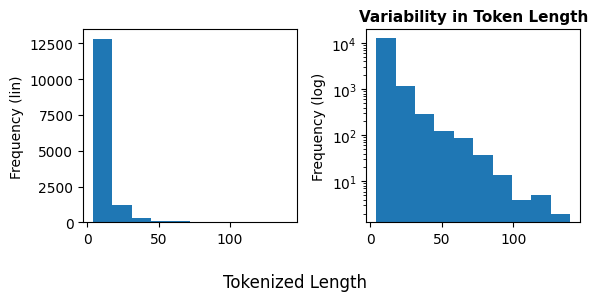

In [5]:
# display histogram of the frequency of tokenized length
fig, ax = plt.subplots(1, 2, figsize=(6,3))

### chart scaling
ax[1].set_yscale('log')

### data
ax[0].hist(tokens_len, label='Tokenized SMILEs Length')
ax[1].hist(tokens_len, label='Tokenized SMILEs Length')

### chart labels
plt.title(
    f'Variability in Token Length', 
    fontweight='bold', fontsize=11
)
fig.supxlabel('Tokenized Length')
ax[0].set_ylabel('Frequency (lin)')
ax[1].set_ylabel('Frequency (log)')

fig.tight_layout()
plt.show()

In [6]:
# filter dataframe by token length to avoid ???
filter_to_length = 20
logPdata_filtered = logPdata[logPdata['Tokenized Length'] < filter_to_length]

print('log(P) DataFrame shape after filtering: ', logPdata_filtered.shape)

log(P) DataFrame shape after filtering:  (13288, 4)


In [7]:
# split into training and testing datasets
split_data = train_test_split(
    logPdata_filtered, test_size=0.1, shuffle=True
    )

train, test = split_data[0], split_data[1]

print('Training data shape: ', train.shape)
print('Testing data shape: ', test.shape)

Training data shape:  (11959, 4)
Testing data shape:  (1329, 4)


#### 1.1 | Visualise SMILES

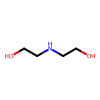

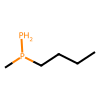

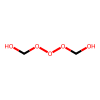

In [8]:
# create list of SMILES
SMILES_list = logPdata['SMILES'].values.tolist()

# create Mol objects from SMILES
ms = [Chem.MolFromSmiles(smi) for smi in SMILES_list[9:12]]   ### 'SMILES_list' sliced to visualise selected values only

# visualise Mol objects
for m in ms:
    img = Draw.MolToImage(m, size=(100,100))
    display(img)

## 2 | Example from GeeksforGeeks

In [9]:
np.random.seed(0)
torch.manual_seed(0)

t = np.linspace(0, 100, 1000)
data = np.sin(t)

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)\
    
seq_length = 10
X, y = create_sequences(data, seq_length)

trainX = torch.tensor(X[:, :, None], dtype = torch.float32)
trainY = torch.tensor(y[:, None], dtype=torch.float32)

X.shape, type(X), y.shape, type(y), trainX.shape, trainY.shape

((990, 10),
 numpy.ndarray,
 (990,),
 numpy.ndarray,
 torch.Size([990, 10, 1]),
 torch.Size([990, 1]))

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, h0=None, c0=None):
        if h0 is None or c0 is None:
            h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)
            c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)

        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])

        return out, hn, cn

In [11]:
model = LSTMModel(input_dim=1, hidden_dim=100, layer_dim=1, output_dim=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [12]:
num_epochs = 100
h0, c0 = None, None

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs, h0, c0 = model(trainX, h0, c0)

    loss = criterion(outputs, trainY)
    loss.backward()
    optimizer.step()

    h0, c0 = h0.detach(), c0.detach()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.2866
Epoch [20/100], Loss: 0.0900
Epoch [30/100], Loss: 0.0379
Epoch [40/100], Loss: 0.0184
Epoch [50/100], Loss: 0.0027
Epoch [60/100], Loss: 0.0004
Epoch [70/100], Loss: 0.0008
Epoch [80/100], Loss: 0.0003
Epoch [90/100], Loss: 0.0001
Epoch [100/100], Loss: 0.0001


tensor([[ 0.8387],
        [ 0.8867],
        [ 0.9264],
        [ 0.9575],
        [ 0.9797],
        [ 0.9928],
        [ 0.9965],
        [ 0.9908],
        [ 0.9755],
        [ 0.9507],
        [ 0.9163],
        [ 0.8726],
        [ 0.8197],
        [ 0.7579],
        [ 0.6877],
        [ 0.6098],
        [ 0.5250],
        [ 0.4343],
        [ 0.3387],
        [ 0.2396],
        [ 0.1381],
        [ 0.0356],
        [-0.0667],
        [-0.1675],
        [-0.2658],
        [-0.3608],
        [-0.4514],
        [-0.5369],
        [-0.6168],
        [-0.6904],
        [-0.7571],
        [-0.8164],
        [-0.8678],
        [-0.9110],
        [-0.9455],
        [-0.9711],
        [-0.9875],
        [-0.9945],
        [-0.9919],
        [-0.9797],
        [-0.9579],
        [-0.9264],
        [-0.8855],
        [-0.8353],
        [-0.7762],
        [-0.7086],
        [-0.6331],
        [-0.5505],
        [-0.4617],
        [-0.3677],
        [-0.2697],
        [-0.1690],
        [-0.

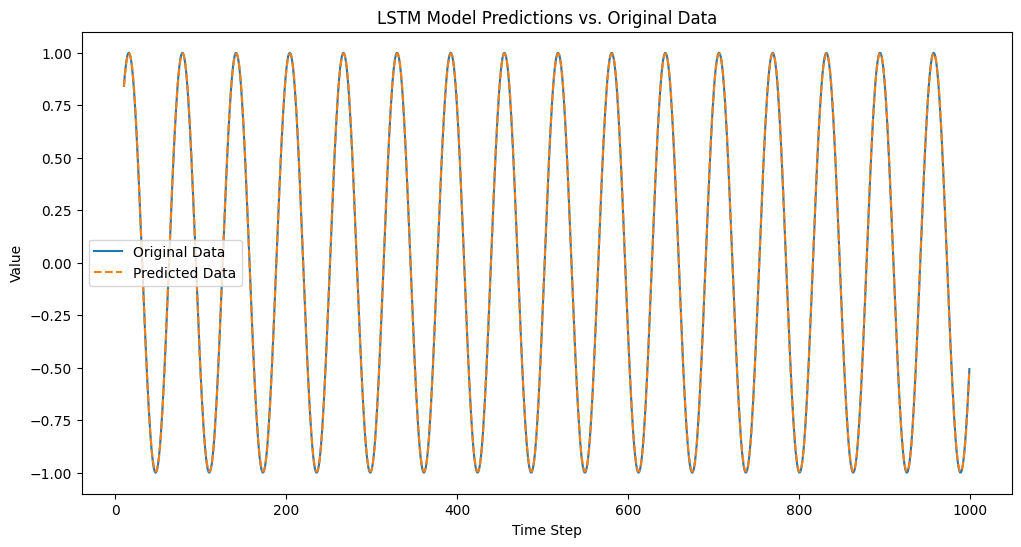

In [13]:
model.eval()
predicted, _, _ = model(trainX, h0, c0)
print(predicted)

original = data[seq_length:]
time_steps = np.arange(seq_length, len(data))

#predicted[::30] += 0.2
#predicted[::70] -= 0.2

plt.figure(figsize=(12,6))
plt.plot(time_steps, original, label='Original Data')
plt.plot(time_steps, predicted.detach().numpy(), label='Predicted Data', linestyle='--')
plt.title('LSTM Model Predictions vs. Original Data')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.show()

# 3 | Real Thing

In [14]:
# format training data - descriptors
def format_descriptors(data:pd.DataFrame, max_token_len:int):
    '''
    ???
    '''
    # create blank numpy.array object of correct size
    X = np.zeros((len(data), max_token_len))

    # overwrite blank numpy.array with tokenised data
    # ensures length of all entries is standardised by padding with '0' values
    for i, token in zip(np.arange(0,len(data),1), data['Tokenize']):
        token_arr = np.asarray(token)
        X[i][:len(token_arr)] = token_arr

    # convert to torch.tensor object
    X = torch.tensor(X[:, :, None], dtype = torch.float32)

    print('Shape of Descriptor Data: ', X.shape)

    return X


# format training data - labels
def format_labels(data):
    '''
    ???
    '''
    # convert Clog(P) data to a torch.tensor object
    Y = np.asarray(data['ClogP'])
    Y = torch.tensor(Y[:, None], dtype=torch.float32)

    print('Shape of True Value Data: ', Y.shape)

    return Y

In [15]:
# format training and testing data
trainX = format_descriptors(train, filter_to_length)     ### training data descriptors
testX = format_descriptors(test, filter_to_length)     ### testing data descriptors

trainY_true = format_labels(train)     ### training data true Clog(P) values
testY_true = format_labels(test)     ### testing data true Clog(P) values

Shape of Descriptor Data:  torch.Size([11959, 20, 1])
Shape of Descriptor Data:  torch.Size([1329, 20, 1])
Shape of True Value Data:  torch.Size([11959, 1])
Shape of True Value Data:  torch.Size([1329, 1])


In [16]:
# define the NN model architecture
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        '''
        ???
        '''
        super(LSTMModel, self).__init__()

        # define internal variables
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim

        # ???
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)


    def forward(self, x, h0=None, c0=None):
        '''
        ???
        '''
        # ???
        if h0 is None or c0 is None:
            h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)
            c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)

        # ???
        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])

        return out, hn, cn

In [17]:
# instantiate model, criterion, and optimizer ???
model = LSTMModel(input_dim=1, hidden_dim=100, layer_dim=1, output_dim=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [18]:
# ???
num_epochs = 1000
h0, c0 = None, None

# blank list to store loss values 
loss_by_epoch = list()

# ???
for epoch in range(num_epochs):
    # switch to model training mode
    model.train()
    optimizer.zero_grad()

    outputs, h0, c0 = model(trainX, h0, c0)

    loss = criterion(outputs, trainY_true)
    loss.backward()

    optimizer.step()
    
    h0, c0 = h0.detach(), c0.detach()
    
    # add loss value to storage list
    loss_by_epoch.append(loss.item())

    # print every 5th loss value during model training
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [5/1000], Loss: 1.5544
Epoch [10/1000], Loss: 1.5541
Epoch [15/1000], Loss: 1.5502
Epoch [20/1000], Loss: 1.5415
Epoch [25/1000], Loss: 1.5320
Epoch [30/1000], Loss: 1.4762
Epoch [35/1000], Loss: 1.5778
Epoch [40/1000], Loss: 1.5515
Epoch [45/1000], Loss: 1.4630
Epoch [50/1000], Loss: 1.3672
Epoch [55/1000], Loss: 1.4196
Epoch [60/1000], Loss: 1.3682
Epoch [65/1000], Loss: 1.4040
Epoch [70/1000], Loss: 1.3805
Epoch [75/1000], Loss: 1.3478
Epoch [80/1000], Loss: 1.3186
Epoch [85/1000], Loss: 1.3414
Epoch [90/1000], Loss: 1.3580
Epoch [95/1000], Loss: 1.3280
Epoch [100/1000], Loss: 1.3243
Epoch [105/1000], Loss: 1.3452
Epoch [110/1000], Loss: 1.3118
Epoch [115/1000], Loss: 1.3228
Epoch [120/1000], Loss: 1.3122
Epoch [125/1000], Loss: 1.3114
Epoch [130/1000], Loss: 1.3020
Epoch [135/1000], Loss: 1.3052
Epoch [140/1000], Loss: 1.3057
Epoch [145/1000], Loss: 1.3039
Epoch [150/1000], Loss: 1.3491
Epoch [155/1000], Loss: 1.3288
Epoch [160/1000], Loss: 1.2978
Epoch [165/1000], Loss: 1.28

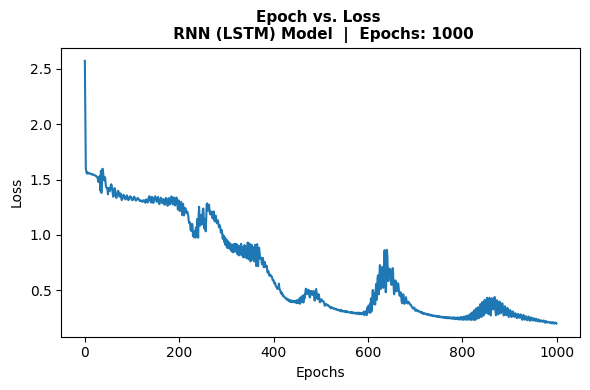

In [19]:
# plot loss values per epoch
fig, ax = plt.subplots(1, 1, figsize=(6,4))

### enumerate epochs
x_vals = range(0, len(loss_by_epoch), 1)

### data
ax.plot(x_vals, loss_by_epoch)

### chart labels
plt.title(
    f'Epoch vs. Loss \n RNN (LSTM) Model  |  Epochs: {num_epochs:.0f}', 
    fontweight='bold', fontsize=11
)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')

fig.tight_layout()
plt.show()

In [20]:
# switch to model evaluation mode
model.eval()

# ???
trainY_pred, _, _ = model(trainX, h0, c0)

trainY_pred_arr = trainY_pred.detach().numpy()#.reshape(1, 11959)
train_error = trainY_pred-trainY_true
train_error = train_error.detach().numpy()

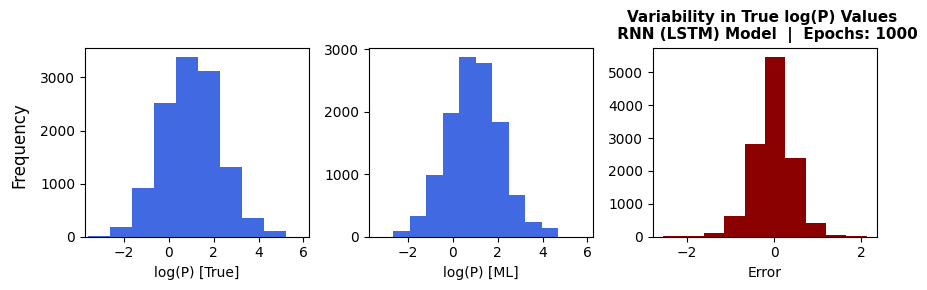

In [21]:
# display histogram of the frequency of true values
fig, ax = plt.subplots(1, 3, figsize=(9,3))

### data
ax[0].hist(trainY_true, label='LogP (True)', color='royalblue')
ax[1].hist(trainY_pred_arr, label='LogP (ML)', color='royalblue')
ax[2].hist(train_error, label='Error', color='darkred')

### chart size
ax[0].set_xlim(-3.75, 6.25)
ax[1].set_xlim(-3.75, 6.25)

### chart labels
fig.supylabel('Frequency')
plt.title(
    f'Variability in True log(P) Values \n RNN (LSTM) Model  |  Epochs: {num_epochs:.0f}', 
    fontweight='bold', fontsize=11
)
ax[0].set_xlabel('log(P) [True]')
ax[1].set_xlabel('log(P) [ML]')
ax[2].set_xlabel('Error')

fig.tight_layout()
plt.show()

In [22]:
model.eval()
testY_pred, _, _ = model(testX, None, None)

testY_pred_arr = testY_pred.detach().numpy()#.reshape(1, 11959)
test_error = testY_pred-testY_true
test_error = test_error.detach().numpy()

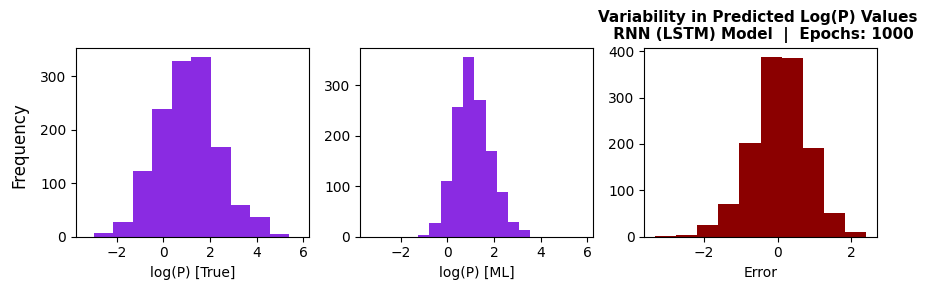

In [23]:
# display histogram of the frequency of true values
fig, ax = plt.subplots(1, 3, figsize=(9,3))

### data
ax[0].hist(testY_true, label='LogP (True)', color='blueviolet')
ax[1].hist(testY_pred_arr, label='LogP (ML)', color='blueviolet')
ax[2].hist(test_error, label='Error', color='darkred')

### chart size
ax[0].set_xlim(-3.75, 6.25)
ax[1].set_xlim(-3.75, 6.25)

### chart labels
fig.supylabel('Frequency')
plt.title(
    f'Variability in Predicted Log(P) Values \n RNN (LSTM) Model  |  Epochs: {num_epochs:.0f}', 
    fontweight='bold', fontsize=11
)
ax[0].set_xlabel('log(P) [True]')
ax[1].set_xlabel('log(P) [ML]')
ax[2].set_xlabel('Error')

fig.tight_layout()
plt.show()

In [24]:
# add predicted values and error from true values to log(P) DataFrame 
    # for training and testing data
train['ClogP (Predicted)'] = trainY_pred_arr
train['Error'] = train_error

test['ClogP (Predicted)'] = testY_pred_arr
test['Error'] = test_error

In [25]:
# calculate root mean square error for training and testing data
rmse_train = np.sqrt(
    mean_squared_error(train['ClogP'], train['ClogP (Predicted)'])
)

rmse_test = np.sqrt(
    mean_squared_error(test['ClogP'], test['ClogP (Predicted)'])
)

print(f'Training RMSE: {rmse_train:.5f}')
print(f'Testing RMSE: {rmse_test:.5f}')

Training RMSE: 0.44520
Testing RMSE: 0.75514


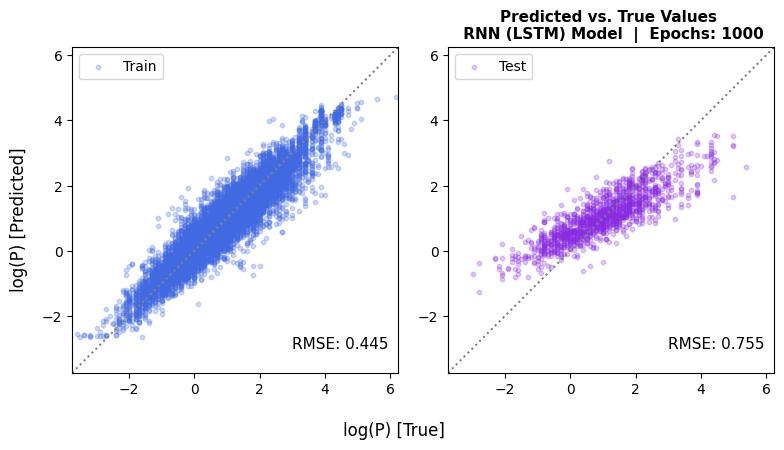

In [27]:
# plot true vs. predicted log(P) values for training and testing data 
fig, ax = plt.subplots(1, 2, figsize=(8,4.5))

### data
ax[0].scatter(train['ClogP'], train['ClogP (Predicted)'], c='royalblue', s=10, alpha=0.25, label='Train')
ax[1].scatter(test['ClogP'], test['ClogP (Predicted)'], c='blueviolet', s=10, alpha=0.25, label='Test')

### ideal fit
ax[0].plot(np.linspace(-3.75,6.25,50),np.linspace(-3.75,6.25,50), c='grey', linestyle=":")
ax[1].plot(np.linspace(-3.75,6.25,50),np.linspace(-3.75,6.25,50), c='grey', linestyle=":")

### chart size
ax[0].set_xlim(-3.75, 6.25)
ax[0].set_ylim(-3.75, 6.25)
ax[1].set_xlim(-3.75, 6.25)
ax[1].set_ylim(-3.75, 6.25)

### legends
ax[0].legend()
ax[1].legend()

### chart labels
fig.supxlabel('log(P) [True]')
fig.supylabel('log(P) [Predicted]')
plt.title(
    f'Predicted vs. True Values \n RNN (LSTM) Model  |  Epochs: {num_epochs:.0f}', 
    fontweight='bold', fontsize=11
)

### annotate with RMSEs
ax[0].annotate(f'RMSE: {rmse_train:.3f}', xy=(3,-3), fontsize=11)
ax[1].annotate(f'RMSE: {rmse_test:.3f}', xy=(3,-3), fontsize=11)

fig.tight_layout()
plt.show()